# Assignment 1 - Part 1 — Forward Pass
**Introduction to Deep Learning, THWS**

In this part of the assignment you will build the forward pass of a neural network from scratch.
You will work with a small regression dataset and implement increasingly general building blocks —
starting from a scalar linear function and ending with a two-layer MLP.

**How to work:**
- All your implementations go in `layers.py`.
- Edit the file in your editor, save, then re-run the cells here to test your work.
- The `%autoreload` magic at the top means you do **not** need to restart the kernel after editing — just re-run the cell.
- Use only PyTorch tensor operations. Do not use `torch.nn` or `numpy`.

**Submission:** zip the notebook `part1_forward.ipynb` and `layers.py` together and submit via E-Learning as a single `A1P1.zip` before the deadline.

**Team Members - put here your names!:** Name1, Name2

In [2]:
%load_ext autoreload
%autoreload 2

import torch
from helpers import load_data
from plotting import plot_data, plot_fit

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## The dataset

We work with a synthetic housing dataset. Each example represents a flat described by four features:

| Feature | Description |
|---|---|
| `age` | Age of the building (years) |
| `size` | Floor area (m²) |
| `distance` | Distance to city centre (km) |
| `floor` | Floor number |

The target `price` is the flat's price in standardised units.
All features and the target have been standardised (zero mean, unit standard deviation).

Run the cell below to load the data and inspect its shape.

In [5]:
X, y = load_data()
print(f'X shape: {X.shape}')   # (N, 4)
print(f'y shape: {y.shape}')   # (N, 1)
print(f'\nFirst example:')
print(f'  features: {X[0]}')
print(f'  price:    {y[0].item():.4f}')

X shape: torch.Size([500, 4])
y shape: torch.Size([500, 1])

First example:
  features: tensor([ 0.5304, -0.3998,  0.7947,  0.5247])
  price:    -0.9119


Let's visualise the two features with the strongest relationship to price.

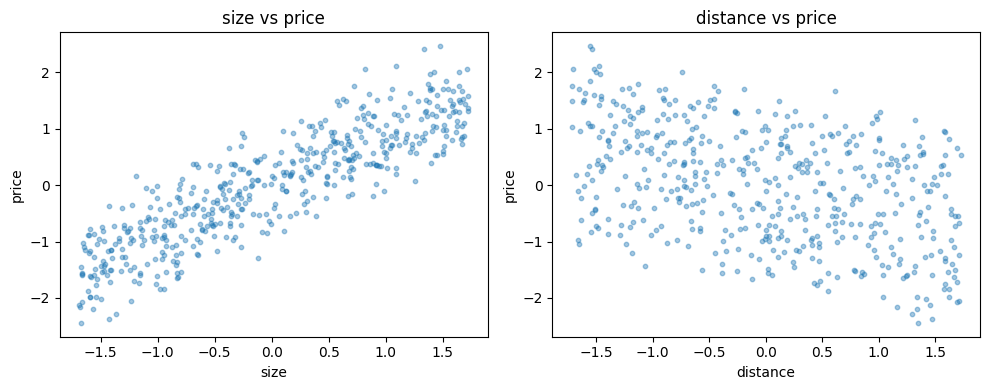

In [6]:
plot_data(X, y)

---
## Section 1 — Scalar forward pass

We start with the simplest possible case: a single data point with a single input feature,
and a linear prediction function.

The prediction for a scalar input $x$ with parameters $\boldsymbol{\theta} = (\theta_0, \theta_1)$ is:

$$\hat{y} = \theta_1 \cdot x + \theta_0$$

The quality of the prediction is measured by the squared error:

$$L = (\hat{y} - y)^2$$

**Task 1.1** Implement `linear_scalar(x, theta)` in `layers.py`.

In [27]:
from layers import linear_scalar

# use the first example, first feature only
x = X[0, 0].item()   # scalar: age of first flat
y0 = y[0].item()     # scalar: price of first flat

# arbitrary initial parameters
theta = torch.tensor([0.0, 1.0])   # theta_0 = 0, theta_1 = 1

y_pred = linear_scalar(x, theta)
print(f'x:      {x:.4f}')
print(f'y:      {y0:.4f}')
print(f'y_pred: {y_pred:.4f}')

x:      0.5304
y:      -0.9119
y_pred: 0.5304


**Task 1.2** Implement `squared_error(y_pred, y)` in `layers.py`.

In [28]:
from layers import squared_error

loss = squared_error(y_pred, y0)
print(f'squared error: {loss:.4f}')

squared error: 2.0802


**Question 1.1** Try changing `theta` to `torch.tensor([0.5, 0.0])` and re-run the two cells above.
What is the squared error now? Why?

*Answer:* After taking theta[0] = 0.5 and theta[1] = 0.0 now my squared error is 1.9934

---
## Section 2 — Batch forward pass

Working one example at a time is impractical. We now vectorise:
given a batch of $N$ inputs $X \in \mathbb{R}^{N \times d}$,
we compute all $N$ predictions in one shot.

With weight matrix $\Theta_1 \in \mathbb{R}^{d_{out} \times d_{in}}$ and bias $\Theta_0 \in \mathbb{R}^{1 \times d_{out}}$:

$$\hat{Y} = X \, \Theta_1^\top + \Theta_0 \qquad \hat{Y} \in \mathbb{R}^{N \times d_{out}}$$

The mean squared error over the batch is:

$$L = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}^{(i)} - y^{(i)})^2$$

**Task 2.1** Implement `linear_forward(X, theta_1, theta_0)` in `layers.py`.

In [20]:
from layers import linear_forward

# linear model: 4 inputs -> 1 output
torch.manual_seed(0)
theta_1 = torch.randn(1, 4)   # shape (out_features, in_features)
theta_0 = torch.zeros(1, 1)   # shape (1, out_features)

y_pred = linear_forward(X, theta_1, theta_0)
print(f'y_pred shape: {y_pred.shape}')          # expect (500, 1)
print(f'First 5 predictions: {y_pred[:5].squeeze().tolist()}')

y_pred shape: torch.Size([500, 1])
First 5 predictions: [-0.49851715564727783, 0.37503552436828613, 1.9891932010650635, -0.20115354657173157, 0.2957409620285034]


**Task 2.2** Implement `mse_forward(y_pred, y)` in `layers.py`.

In [22]:
from layers import mse_forward

loss = mse_forward(y_pred, y)
print(f'MSE (random weights): {loss.item():.4f}')

MSE (random weights): 7.6729


**Question 2.1** What would MSE = 0 mean? Is it achievable with this linear model on this dataset?

*Answer:* MSE = 0 would mean the model predicts every value perfectly with zero error. It is not achievable with this linear model because the data contains noise and complex non-linear relationships that a simple linear function cannot capture perfectly.

**Question 2.2** The target `y` has been standardised to have mean 0 and standard deviation 1.
A model that always predicts 0 (i.e. `theta_1 = 0, theta_0 = 0`) gives MSE = 1.0 on this data.
Run the cell below to verify, then explain why.

*Answer:* When I ran the cell I got MSE = 0.9980 which is basically 1.0. The reason this happens is because y has been standardised to have mean 0 and standard deviation 1. When the model always predicts 0, the MSE becomes the average of (0 - y)² which is just the average of y² squared values. Since the mean of y is 0, this average of squared values is exactly the variance of y. And since standard deviation is 1, the variance is 1² = 1.0.
So basically predicting zero always gives MSE equal to the variance of the data which is 1.0. This is also why MSE = 1.0 is our baseline any trained model should do better than just predicting zero every time.

In [23]:
# constant-zero predictor baseline
y_zero = torch.zeros_like(y)
print(f'MSE (zero predictor): {mse_forward(y_zero, y).item():.4f}')

MSE (zero predictor): 0.9980


Now let's visualise how well the linear model fits the data. We plot size vs price and overlay the model's predictions, varying size across its range while keeping other features at their mean.

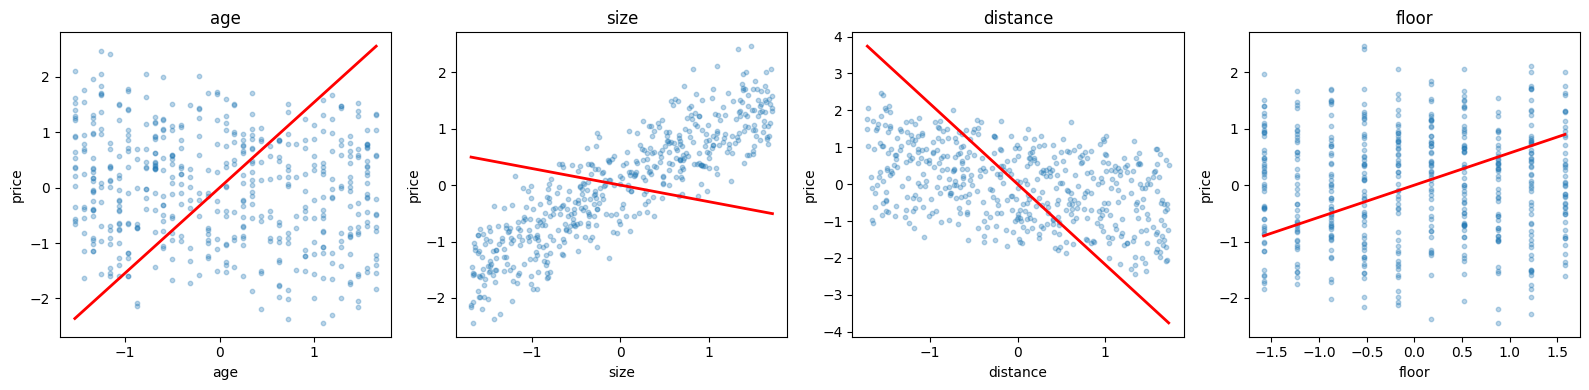

In [19]:
# build the same linear model as a Model object for plot_fit
torch.manual_seed(0)
from layers import Model, Linear
lin_model = Model([Linear(theta_1=torch.randn(1, 4), theta_0=torch.zeros(1, 1))])
plot_fit(X, y, lin_model)

---
## Section 3 — Linear layer class

Standalone functions work fine for a single layer, but as networks grow deeper,
we need to keep track of each layer's parameters and the values it computed.
We encapsulate this in a class.

The `Linear` class stores its parameters `theta_1` and `theta_0`,
and its `forward` method also saves the input (`self.ins`) and output (`self.outs`).
You will see why in Part 2 — the stored values are needed for the backward pass.

**Task 3.1** Implement `Linear.__init__` and `Linear.forward` in `layers.py`.

In [20]:
from layers import Linear

torch.manual_seed(0)
layer = Linear(
    theta_1=torch.randn(1, 4),   # (out_features, in_features)
    theta_0=torch.zeros(1, 1),   # (1, out_features)
)

y_pred = layer.forward(X)
print(f'Output shape: {y_pred.shape}')                          # expect (500, 1)
print(f'ins stored:   {layer.ins.shape}')                       # expect (500, 4)
print(f'outs stored:  {layer.outs.shape}')                      # expect (500, 1)

# should match linear_forward with same parameters
torch.manual_seed(0)
y_ref = linear_forward(X, torch.randn(1, 4), torch.zeros(1, 1))
print(f'Matches linear_forward: {torch.allclose(y_pred, y_ref)}')

Output shape: torch.Size([500, 1])
ins stored:   torch.Size([500, 4])
outs stored:  torch.Size([500, 1])
Matches linear_forward: True


---
## Section 4 — ReLU class

The ReLU non-linearity applies $a(z) = \max(0, z)$ element-wise.
It introduces non-linearity between linear layers, allowing the network to learn curved decision boundaries.

Like `Linear`, the `ReLU` class stores its input (`self.ins`) and output (`self.outs`) during the forward pass.

**Task 4.1** Implement `ReLU.forward` in `layers.py`.

In [23]:
from layers import ReLU

relu = ReLU()

# small hand-crafted example
z = torch.tensor([[-1.5,  0.0,  2.3],
                  [ 0.7, -0.4,  1.1]])
a = relu.forward(z)

print(f'Pre-activations z:\n{z}')
print(f'Activations     a:\n{a}')

Pre-activations z:
tensor([[-1.5000,  0.0000,  2.3000],
        [ 0.7000, -0.4000,  1.1000]])
Activations     a:
tensor([[0.0000, 0.0000, 2.3000],
        [0.7000, 0.0000, 1.1000]])


Expected output:
```
Pre-activations z:
tensor([[-1.5000,  0.0000,  2.3000],
        [ 0.7000, -0.4000,  1.1000]])
Activations     a:
tensor([[0.0000, 0.0000, 2.3000],
        [0.7000, 0.0000, 1.1000]])
```

**Question 4.1** What does ReLU do to negative pre-activations?
Why is this useful in a network between two linear layers?

*Answer:* ... ReLU sets all negative pre-activations to zero while keeping positive values unchanged. For example, when I tested it with values like -1.5 and -0.4, they became 0, while 2.3 and 0.7 stayed the same.
If you stack two linear layers without anything in between, mathematically they just combine into one single linear function. So adding more linear layers without ReLU is completely pointless they collapse into one. But when ReLU sits between them, it breaks this pattern by zeroing out the negatives. This means the network can no longer be reduced to a single straight line it can now bend and curve to fit more complex patterns in the data.

---
## Section 5 — Model class and full forward pass

We now assemble layers into a full network using the `Model` class.
`Model` holds an ordered list of layers and runs the forward pass by chaining them:
the output of each layer becomes the input of the next.

**Task 5.1** Implement `Model.forward` in `layers.py`.

In [24]:
from layers import Model, Linear, ReLU

# build a two-layer MLP: Linear(4->8) -> ReLU -> Linear(8->1)
torch.manual_seed(0)
model = Model([
    Linear(theta_1=torch.randn(8, 4), theta_0=torch.zeros(1, 8)),
    ReLU(),
    Linear(theta_1=torch.randn(1, 8), theta_0=torch.zeros(1, 1)),
])

y_pred_mlp = model.forward(X)
print(f'MLP output shape: {y_pred_mlp.shape}')   # expect (500, 1)

MLP output shape: torch.Size([500, 1])


Now let's compare the MSE of the linear model and the MLP — both with random (untrained) weights.

In [25]:
# linear model (from Section 2)
torch.manual_seed(0)
linear_model = Model([
    Linear(theta_1=torch.randn(1, 4), theta_0=torch.zeros(1, 1)),
])
y_pred_linear = linear_model.forward(X)
loss_linear = mse_forward(y_pred_linear, y)

# MLP (from above)
loss_mlp = mse_forward(y_pred_mlp, y)

print(f'MSE linear model (random weights): {loss_linear.item():.4f}')
print(f'MSE MLP          (random weights): {loss_mlp.item():.4f}')

MSE linear model (random weights): 7.6729
MSE MLP          (random weights): 10.5908


**Question 5.1** Neither model does well with random weights. What is missing to make these models useful?

*Answer:* What is missing is training. Right now both models have random weights so they are just guessing blindly. To make them useful we need to implement the backward pass to calculate gradients and then use gradient descent to update the weights

**Question 5.2** The MLP has more parameters than the linear model. Does having more parameters
automatically lead to better predictions? Explain.

*Answer:* No, more parameters do not automatically lead to better predictions. As I saw in my results, the MLP with 49 parameters actually gave worse MSE (10.5908) than the linear model with just 5 parameters (7.6729). More parameters only help after proper training without it, more parameters just means more random guessing which makes predictions even worse.

Let's visualise the marginal fits of both models — how each one relates each input feature to the predicted price, with all other features held at zero.

The linear model can only produce straight lines. The MLP, even with random weights, produces curved marginal responses — a hint of the flexibility that training will unlock.

Linear model:


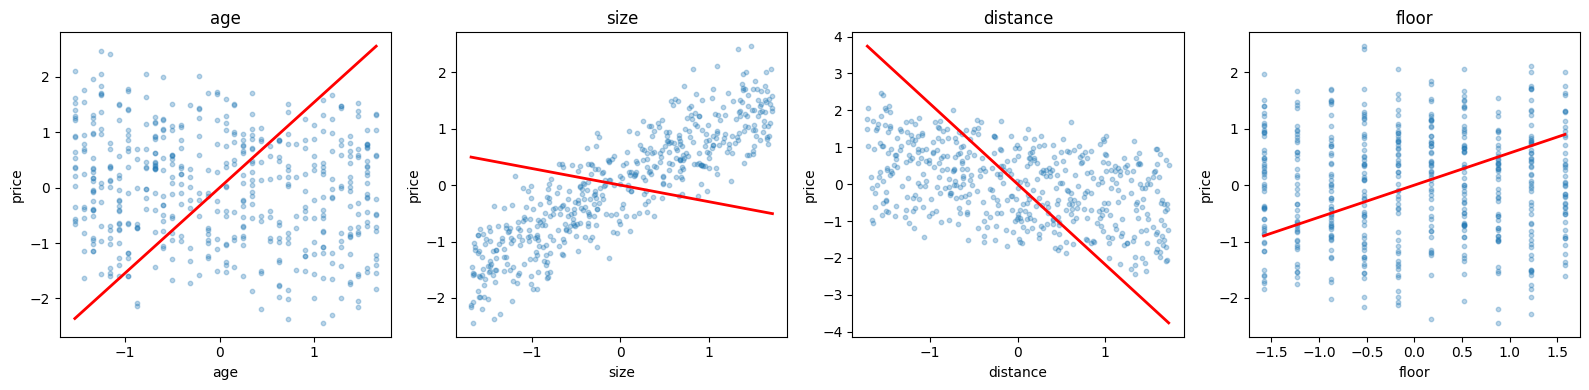

MLP:


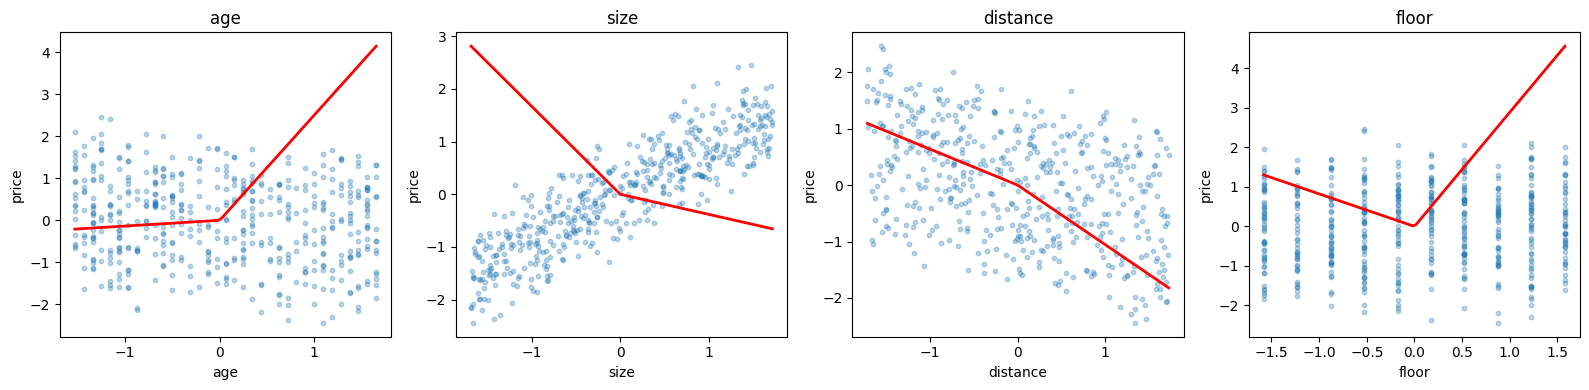

In [26]:
print('Linear model:')
plot_fit(X, y, linear_model)
print('MLP:')
plot_fit(X, y, model)